[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$x_i \in \mathbb{R}$ para $i \in \{1, \dots, 6\}$, que representan los kilogramos a usar de cada uno de los 6 ingredientes (Maíz, Soya, Heno, Melaza, Minerales, Salvado).

**Funcion objetivo:**

Queremos minimizar el costo total de la dieta multiplicando los kilos por su costo unitario: $$\min_{x} 4.5x_1 + 9.0x_2 + 2.5x_3 + 3.0x_4 + 15.0x_5 + 3.5x_6$$

**Restricciones:**
$$\begin{aligned}
3.3x_1 + 3.2x_2 + 2.0x_3 + 2.8x_4 + 0.0x_5 + 2.5x_6 &\geq 25 \quad \text{(Energía min)} \\
90x_1 + 440x_2 + 80x_3 + 40x_4 + 0x_5 + 150x_6 &\geq 1000 \quad \text{(Proteína min)} \\
0.3x_1 + 2.7x_2 + 4.0x_3 + 8.0x_4 + 200x_5 + 1.5x_6 &\geq 30 \quad \text{(Calcio min)} \\
2.8x_1 + 6.5x_2 + 2.0x_3 + 0.8x_4 + 80x_5 + 12.0x_6 &\geq 20 \quad \text{(Fósforo min)} \\
\sum_{i=1}^6 x_i &\geq 8 \quad \text{(Consumo min)} \\
\sum_{i=1}^6 x_i &\leq 12 \quad \text{(Consumo max)} \\
0 \leq x_1 &\leq 6.0 \quad \text{(Cotas Maíz)} \\
0 \leq x_2 &\leq 3.0 \quad \text{(Cotas Soya)} \\
0 \leq x_3 &\leq 5.0 \quad \text{(Cotas Heno)} \\
0 \leq x_4 &\leq 2.0 \quad \text{(Cotas Melaza)} \\
0 \leq x_5 &\leq 0.5 \quad \text{(Cotas Minerales)} \\
0 \leq x_6 &\leq 4.0 \quad \text{(Cotas Salvado)}
\end{aligned}$$

$$\begin{aligned}
& \\
& \\
\end{aligned}$$

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** LP Simplex/Highs, en particular, scipy.optimize.linprog (con el parámetro method="highs")

**Justificacion (2-3 oraciones):** El problema es un caso puro de Programación Lineal (LP), ya que tanto la función objetivo como las restricciones son estrictamente lineales y las variables de decisión (kilogramos) son continuas. Aunque teóricamente el Método Simplex tradicional garantiza encontrar el óptimo global, se elige el solver moderno highs porque el Simplex puro puede sufrir de "ciclado" por degeneración o caer en un tiempo de resolución exponencial en el peor de los casos. HiGHS es el estándar industrial actual de SciPy por ser mucho más rápido y combinar eficientemente variantes modernas del Simplex con métodos de puntos interiores.

In [35]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [36]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    return np.dot(costos_p1, x)

def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    # Calculamos cuántos nutrientes aporta la dieta actual usando np.dot
    nutrientes_totales = np.dot(nutrientes_p1, x)
    intake_total = np.sum(x)

    # Usamos una tolerancia pequeña
    tol = 1e-6

    # Verificamos las 3 condiciones principales:
    # 1 Nutrientes mínimos requeridos
    cumple_nut = np.all(nutrientes_totales >= req_min_p1 - tol)
    # 2 Consumo entre 8 y 12 kg
    cumple_intake = (intake_total >= intake_min_p1 - tol) and (intake_total <= intake_max_p1 + tol)
    # 3 Ingredientes dentro de sus cotas
    cumple_cotas = np.all((x >= -tol) & (x <= max_kg_p1 + tol))

    factible = cumple_nut and cumple_intake and cumple_cotas

    return {
        'factible': factible,
        'nutrientes_totales': nutrientes_totales,
        'intake_total': intake_total
    }


def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    """Resuelve el problema de nutricion animal usando HiGHS."""

    # 1. Vector de costos c (lo que minimizamos)
    c = costos_p1

    # 2. Matriz de desigualdades A_ub (Lado izquierdo)
    # Apilamos las reglas de desigualdad
    A_ub = np.vstack([
        -nutrientes_p1,           # Nutrientes minimos (x -1)
        -np.ones(6),              # Consumo minimo de 8kg (x -1)
        np.ones(6)                # Consumo maximo de 12kg (positivo, ya es <=)
    ])

    # 3. Vector de límites b_ub (Lado derecho)
    # Concatenamos los valores en el mismo orden que la matriz A_ub
    b_ub = np.concatenate([
        -req_min_p1,              # Requerimientos minimos (x -1)
        [-intake_min_p1],         # Consumo minimo (x -1)
        [intake_max_p1]           # Consumo maximo (positivo)
    ])

    # 4. Cotas de las variables (Bounds)
    # Le decimos a scipy entre qué valores puede existir cada variable x_i
    bounds = [(0, max_val) for max_val in max_kg_p1]

    # 5. Ejecutar el optimizador
    resultado = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

    return resultado.x, resultado.fun



Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


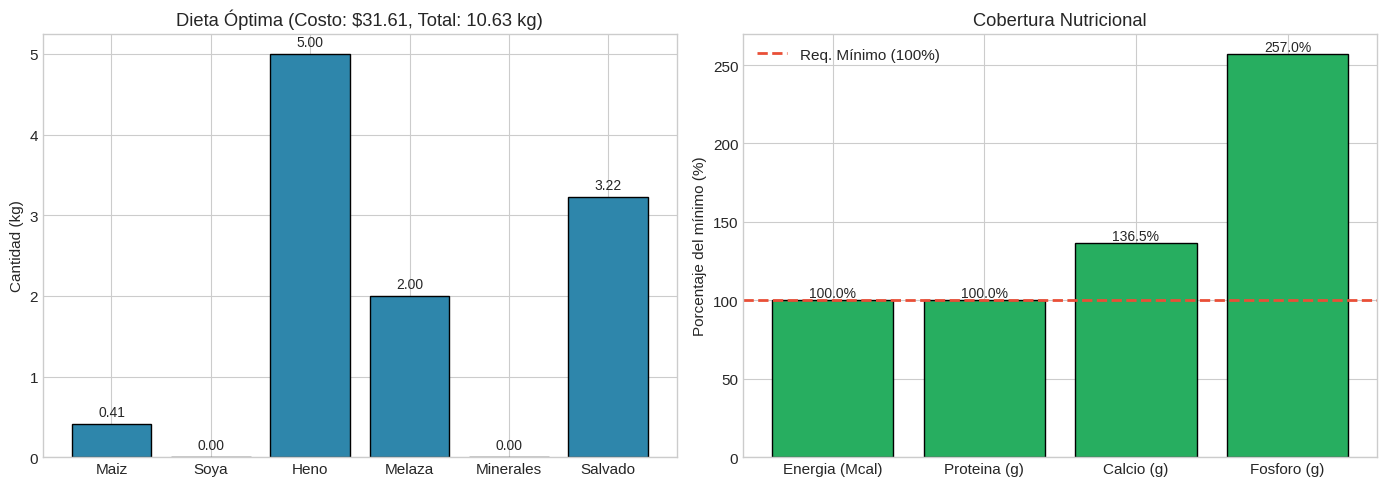

In [37]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    info = verificar_p1(x_opt)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Ingredientes (Cantidades)
    axes[0].bar(nombres_p1, x_opt, color="#2E86AB", edgecolor="black")
    axes[0].set_title(f"Dieta Óptima (Costo: ${costo_opt:.2f}, Total: {info['intake_total']:.2f} kg)")
    axes[0].set_ylabel("Cantidad (kg)")
    for i, kg in enumerate(x_opt):
        axes[0].text(i, kg + 0.1, f"{kg:.2f}", ha='center', fontsize=10)

    # Panel 2: Cumplimiento de Nutrientes (%)
    # Convertimos los nutrientes obtenidos a un porcentaje del minimo requerido
    porcentajes = (info['nutrientes_totales'] / req_min_p1) * 100
    x_pos = np.arange(len(nombres_nutrientes_p1))

    axes[1].bar(x_pos, porcentajes, color="#27AE60", edgecolor="black")
    axes[1].axhline(y=100, color="#E94F37", linestyle="--", linewidth=2, label="Req. Mínimo (100%)")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(nombres_nutrientes_p1)
    axes[1].set_title("Cobertura Nutricional")
    axes[1].set_ylabel("Porcentaje del mínimo (%)")

    for i, pct in enumerate(porcentajes):
        axes[1].text(i, pct + 2, f"{pct:.1f}%", ha='center', fontsize=10)

    axes[1].legend()
    fig.tight_layout()
    plt.show()

# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

Sea $w_i \in \mathbb{R}$ la proporción del capital invertida en el activo $i$, para $i \in \{1, 2, 3, 4, 5\}$.

Donde los activos son (Bonos, Acciones tech, Bienes raíces, Materias primas y Mercados emergentes).

Alternativamente, podemos definir el vector de pesos como $w = [w_1, w_2, w_3, w_4, w_5]^T$.$$w \in \mathbb{R}^5$$

**Funcion objetivo:** Queremos minimizar el riesgo, el cual se mide como la varianza del portafolio. En notación matricial, si $\Sigma$ es la matriz de covarianza, la varianza del portafolio es $w^T \Sigma w$. O bien:
$\min_{w} \sum_{i=1}^5 \sum_{j=1}^5 w_i w_j \Sigma_{ij}$

\
**Restricciones:**
Tenemos que cumplir con un rendimiento mínimo, usar todo el dinero y respetar las cotas superior e inferior por activo.

Usando el vector de rendimientos $r = [0.03, 0.14, 0.08, 0.11, 0.16] ^T$:$$\begin{aligned}\sum_{i=1}^5 r_i w_i &\geq 0.08 \quad \text{(Rendimiento mínimo del 8%)} \\
\sum_{i=1}^5 w_i &= 1 \quad \text{(Invertir el 100% del capital)} \\
 \  0 \leq w_i \leq 0.40 \quad \text{para todo } i \in {1, \dots, 5} \quad \text{(Cotas: sin cortos y máximo 40%)}\end{aligned}$$

$$\begin{aligned}
& \\
& \\
\end{aligned}$$

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** Este es un caso de Programación Cuadrática (QP), en este caso scipy.optimize.minimize (con el método SLSQP)

**Justificacion (2-3 oraciones):** Este es un problema de Programación Cuadrática (QP) ya que buscamos minimizar una función objetivo cuadrática y estrictamente convexa (la varianza del portafolio) sujeta a restricciones lineales. Se elige minimize con el método SLSQP (Sequential Least SQuares Programming) porque es el algoritmo estándar de SciPy capaz de manejar simultáneamente funciones objetivo no lineales junto con restricciones de igualdad (que los pesos sumen 100%), restricciones de desigualdad (rendimiento mínimo) y cotas específicas para cada variable (0 a 40%).

In [38]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [39]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    # Matemáticamente buscamos: w^T * Cov * w
    # Multiplicamos la matriz de covarianza por el vector de pesos (Cov * w)
    cov_por_w = np.dot(cov_p2, w)
    # Multiplicamos el vector de pesos por el resultado anterior
    varianza = np.dot(w, cov_por_w)
    return varianza


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
            'factible': bool
            'rendimiento': float -- rendimiento esperado del portafolio
            'varianza': float
            'suma_pesos': float
    """
    """Verifica si el portafolio cumple todas las restricciones."""
    # Usamos np.dot para calcular el rendimiento total (Rendimientos * pesos)
    rendimiento = np.dot(rendimientos_p2, w)
    varianza = objetivo_p2(w)
    suma_pesos = np.sum(w)

    tol = 1e-6

    # 1. Rendimiento es mayor o igual al 8%?
    cumple_rendimiento = rendimiento >= (retorno_minimo_p2 - tol)

    # 2. Se invirtió todo el dinero
    cumple_suma = abs(suma_pesos - 1.0) <= tol

    # 3. Todos los pesos entre 0% y 40%?
    cumple_cotas = np.all((w >= -tol) & (w <= max_por_activo_p2 + tol))

    factible = cumple_rendimiento and cumple_suma and cumple_cotas

    return {
        'factible': factible,
        'rendimiento': rendimiento,
        'varianza': varianza,
        'suma_pesos': suma_pesos
    }

def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    # 1. Punto de partida (x0): Empezamos siendo ingenuos
    # partes iguales en los 5 activos (20% a cada uno). máx entropía
    w_inicial = np.ones(5) / 5.0

    # 2. Definimos las cotas (bounds):
    # Cada uno de los 5 activos debe estar entre 0.0 y 0.40
    limites = [(0.0, max_por_activo_p2) for _ in range(5)]

    # 3. Definimos las restricciones al estilo diccionario para SLSQP
    restricciones = [
        # Restricción 1: La suma de pesos debe ser 1
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},

        # Restricción 2: El rendimiento debe ser >= 0.08
        {'type': 'ineq', 'fun': lambda w: np.dot(rendimientos_p2, w) - retorno_minimo_p2}
    ]

    # 4. Le pasamos todo al solver SLSQP
    resultado = minimize(
        fun=objetivo_p2,
        x0=w_inicial,
        method='SLSQP',
        bounds=limites,
        constraints=restricciones
    )

    return resultado.x, resultado.fun

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


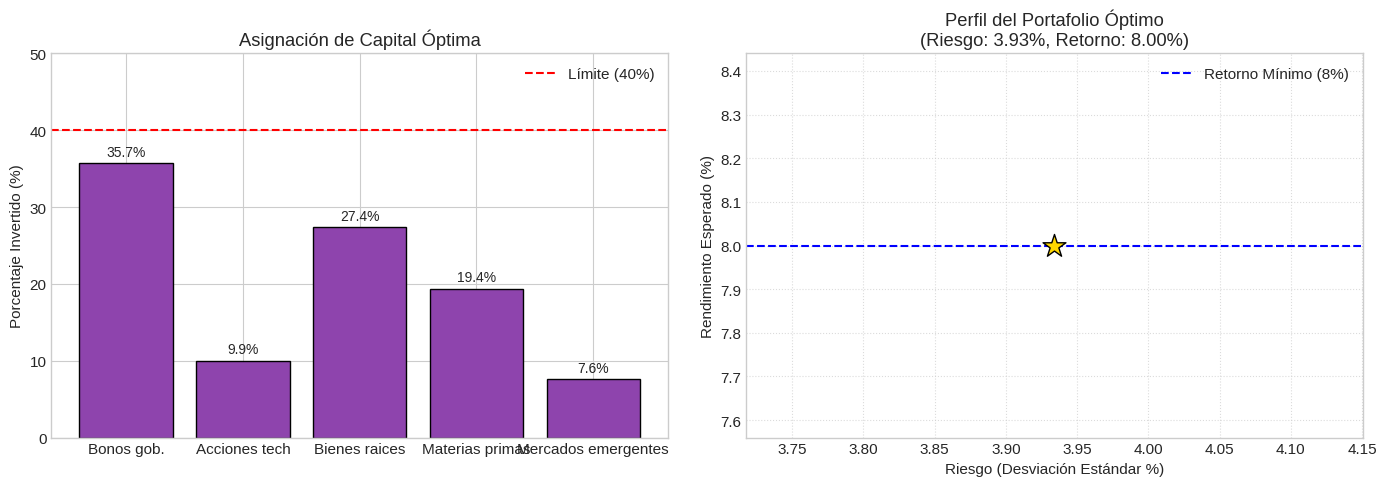

In [40]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    info = verificar_p2(w_opt)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Barras con la asignacion del portafolio (% por activo)
    axes[0].bar(activos_p2, w_opt * 100, color="#8E44AD", edgecolor="black")
    axes[0].set_title("Asignación de Capital Óptima")
    axes[0].set_ylabel("Porcentaje Invertido (%)")
    axes[0].set_ylim(0, 50)  # Dejamos espacio arriba del 40%
    # Dibujamos la línea roja que marca nuestro límite de restricción del 40%
    axes[0].axhline(y=max_por_activo_p2 * 100, color="red", linestyle="--", label="Límite (40%)")

    for i, w in enumerate(w_opt):
        axes[0].text(i, (w*100) + 1, f"{w*100:.1f}%", ha='center', fontsize=10)
    axes[0].legend()

    # Panel 2: Rendimiento vs riesgo del portafolio optimo
    # En finanzas, el riesgo se suele graficar como la desviación estándar (raíz de la varianza)
    riesgo_std = np.sqrt(varianza_opt) * 100
    rendimiento_pct = info['rendimiento'] * 100

    axes[1].scatter([riesgo_std], [rendimiento_pct], color="gold", edgecolors="black", s=300, marker="*", zorder=5)
    axes[1].axhline(y=retorno_minimo_p2 * 100, color="blue", linestyle="--", label="Retorno Mínimo (8%)")

    axes[1].set_title(f"Perfil del Portafolio Óptimo\n(Riesgo: {riesgo_std:.2f}%, Retorno: {rendimiento_pct:.2f}%)")
    axes[1].set_xlabel("Riesgo (Desviación Estándar %)")
    axes[1].set_ylabel("Rendimiento Esperado (%)")
    axes[1].grid(True, linestyle=":", alpha=0.7)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

Sea $y_i$ una variable binaria que indica si la torre $i$ se construye ($1$) o no se construye ($0$), para $i \in \{1, 2, 3, 4, 5, 6, 7\}$.
$$y_i \in \{0, 1\} \quad \text{para } i = 1, \dots, 7$$

**Funcion objetivo:**

Queremos minimizar el costo total de construcción. Si una torre se construye ($y_i = 1$), su costo suma al total; si no ($y_i = 0$), no cuesta nada.$$\min_{y} 50y_1 + 80y_2 + 60y_3 + 70y_4 + 90y_5 + 40y_6 + 75y_7$$

**Restricciones:**
Para cada una de las 10 zonas, debemos garantizar que la suma de las torres construidas que la cubren sea mayor o igual a 1 (es decir, al menos una torre activa le da señal). Revisando tu tabla, zona por zona, queda así:

$$\begin{aligned}
y_1 + y_6 &\geq 1 \quad \text{(Cobertura Zona 1)} \\
y_1 + y_2 &\geq 1 \quad \text{(Cobertura Zona 2)} \\
y_1 + y_2 + y_7 &\geq 1 \quad \text{(Cobertura Zona 3)} \\
y_2 + y_3 &\geq 1 \quad \text{(Cobertura Zona 4)} \\
y_2 + y_3 + y_4 &\geq 1 \quad \text{(Cobertura Zona 5)} \\
y_3 + y_4 + y_7 &\geq 1 \quad \text{(Cobertura Zona 6)} \\
y_4 + y_5 + y_7 &\geq 1 \quad \text{(Cobertura Zona 7)} \\
y_4 + y_5 &\geq 1 \quad \text{(Cobertura Zona 8)} \\
y_5 + y_6 &\geq 1 \quad \text{(Cobertura Zona 9)} \\
y_5 + y_6 &\geq 1 \quad \text{(Cobertura Zona 10)} \\
\end{aligned}$$

### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** Programación Entera Binaria (MILP), en específico scipy.optimize.milp

**Justificacion (2-3 oraciones):** El problema es de Programación Entera Binaria (un caso específico de MILP), ya que la función objetivo y todas las restricciones son estrictamente lineales, pero las variables de decisión están restringidas a ser números enteros (0 o 1). No podemos usar Programación Lineal pura (linprog) porque nos daría resultados fraccionarios (ej. "construir media torre"). Se elige milp porque utiliza algoritmos de ramificación y acotamiento (Branch-and-Bound) que garantizan encontrar la solución óptima exacta respetando la naturaleza discreta de las variables.

In [41]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [42]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    # Multiplicamos los costos por nuestra decisión y (1 si se construye, 0 si no)
    return np.dot(costos_torres_p3, y)

def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool -- True si todas las zonas estan cubiertas
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    # redondeamos por seguridad
    y_redondeado = np.round(y)

    # El arreglo cobertura_p3 tiene dimensiones (7 torres, 10 zonas).
    # Si multiplicamos y (7,) por cobertura_p3 (7, 10), obtenemos un arreglo
    # de tamaño (10,) que nos dice cuántas torres cubren cada una de las 10 zonas.
    cobertura_total = np.dot(y_redondeado, cobertura_p3)

    # Es factible si todas las zonas tienen un valor >= 1
    factible = np.all(cobertura_total >= 1)

    # Extraemos qué zonas sí se cubrieron y cuáles faltaron (sumamos 1 para que empiece en Zona 1)
    zonas_cubiertas = [j+1 for j in range(n_zonas_p3) if cobertura_total[j] >= 1]
    zonas_sin_cubrir = [j+1 for j in range(n_zonas_p3) if cobertura_total[j] < 1]

    return {
        'factible': factible,
        'zonas_cubiertas': zonas_cubiertas,
        'zonas_sin_cubrir': zonas_sin_cubrir
    }

def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """
    # 1. Vector de costos (c) a minimizar
    c = costos_torres_p3

    # 2. Restricciones: Al menos 1 torre por zona.
    # Nuestra matriz cobertura_p3 tiene las zonas en las columnas (7x10),
    # pero scipy espera que las zonas sean las filas. Usamos .T para transponerla a (10x7).
    A = cobertura_p3.T

    # Creamos la restricción: lb (lower bound) es 1 para todas las zonas, ub (upper) es infinito.
    # Esto equivale a A * y >= 1
    restricciones = LinearConstraint(A, lb=np.ones(n_zonas_p3), ub=np.inf)

    # 3. Variables enteras (Integrality)
    # Le decimos a scipy que las 7 variables deben ser tratadas como números enteros (1)
    es_entero = np.ones(n_torres_p3)

    # 4. Cotas (Bounds)
    # Le decimos que las variables no pueden pasar de 0 y 1 (para hacerlas binarias)
    limites = Bounds(0, 1)

    # 5. Ejecutamos el solver MILP (Mixed-Integer Linear Programming)
    resultado = milp(
        c=c,
        constraints=restricciones,
        integrality=es_entero,
        bounds=limites
    )

    # Retornamos la selección (redondeada a enteros absolutos) y el costo
    return np.round(resultado.x), resultado.fun

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


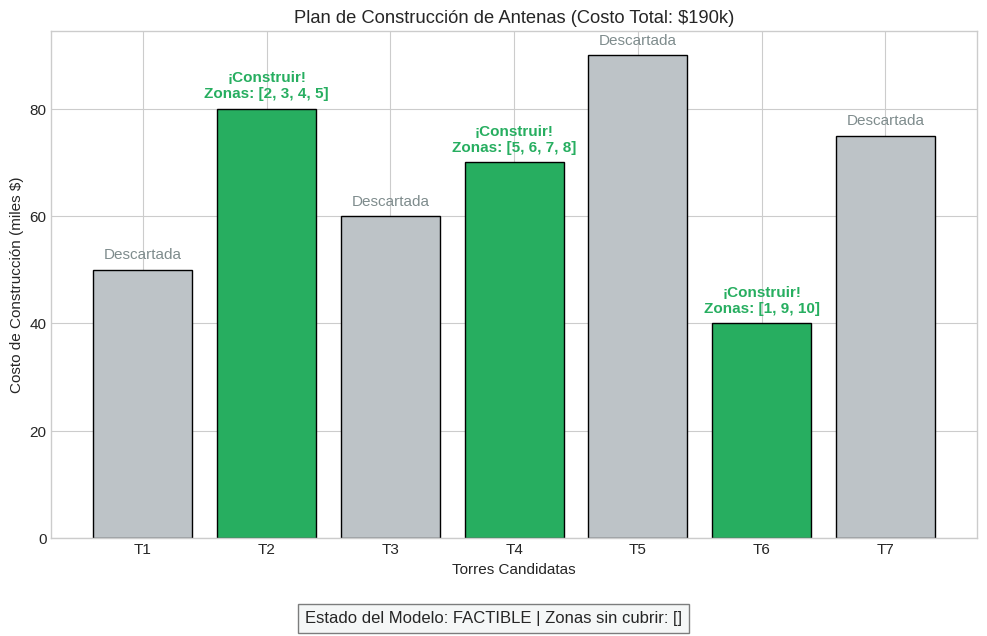

In [43]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura.

    Debe mostrar:
    - Que torres se seleccionaron (con costos)
    - Que zonas cubre cada torre seleccionada

    Args:
        y_opt: np.array (7,)
        costo_opt: float
    """
    info = verificar_p3(y_opt)

    plt.figure(figsize=(10, 6))

    # Colores: Verde si se construye (1), Gris si se ignora (0)
    colores = ["#27AE60" if val > 0.5 else "#BDC3C7" for val in y_opt]

    barras = plt.bar(nombres_torres_p3, costos_torres_p3, color=colores, edgecolor="black")

    plt.title(f"Plan de Construcción de Antenas (Costo Total: ${costo_opt:.0f}k)")
    plt.ylabel("Costo de Construcción (miles $)")
    plt.xlabel("Torres Candidatas")

    # Añadir el texto en las barras
    for i, (barra, seleccionado) in enumerate(zip(barras, y_opt)):
        altura = barra.get_height()
        if seleccionado > 0.5:
            # Si se construye, listamos las zonas que cubre
            zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
            plt.text(barra.get_x() + barra.get_width()/2., altura + 2,
                     f"¡Construir!\nZonas: {zonas}", ha='center', color="#27AE60", fontweight="bold")
        else:
            plt.text(barra.get_x() + barra.get_width()/2., altura + 2,
                     "Descartada", ha='center', color="#7F8C8D")

    # Mostrar resumen de validación abajo
    estado = "FACTIBLE" if info['factible'] else "INFACTIBLE"
    plt.figtext(0.5, -0.05, f"Estado del Modelo: {estado} | Zonas sin cubrir: {info['zonas_sin_cubrir']}",
                ha="center", fontsize=12, bbox={"facecolor":"#ECF0F1", "alpha":0.5, "pad":5})

    plt.tight_layout()
    plt.show()

y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

Las variables que nuestro algoritmo debe ajustar son los 4 parámetros continuos del modelo: $a, b, c, d \in \mathbb{R}$. Podemos agruparlos en un vector de parámetros $\theta = [a, b, c, d]^T$.$$\theta \in \mathbb{R}^4$$

**Funcion objetivo:**

Queremos minimizar el error entre las predicciones de nuestro modelo matemático y los 20 datos reales que observó el sensor. La forma estándar de hacer esto es minimizando la Suma de los Errores al Cuadrado (SSE) o el Error Cuadrático Medio (MSE).$$\min_{a,b,c,d} \sum_{i=1}^{20} \left( y_{obs, i} - \left( a \sin(b \cdot t_i + c) + d \cdot e^{-0.1 \cdot t_i} \right) \right)^2$$

**Restricciones:**

En este caso, unicamente tenemos simples cotas (bounds) o límites para el espacio de búsqueda de cada parámetro individual:
$$\begin{aligned}
0 \leq &a \leq 5 \\
0 \leq &b \leq 10 \\
0 \leq &c \leq 2\pi \\
-3 \leq &d \leq
3\end{aligned}$$

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** Se escoge un Algortimo Genético, en particular un scipy.optimize.differential_evolution (también sería válido dual_annealing)

**Justificacion (2-3 oraciones):**  El problema de calibración busca minimizar el error cuadrático de un modelo que incluye un término trigonométrico ($\sin$). Esto provoca que la función objetivo sea altamente no convexa y esté llena de múltiples mínimos locales. Si usáramos un método clásico basado en gradiente (como minimize con L-BFGS-B o SLSQP), el algoritmo se quedaría atrapado en el primer "valle" falso que encuentre. Se elige differential_evolution porque es un algoritmo de búsqueda global estocástica que explora eficientemente todo el espacio definido por las cotas, logrando escapar de los mínimos locales para encontrar los verdaderos parámetros globales sin necesitar un punto de partida inicial. (Se escoge este en vez de dual_annealing, pues es más robusto contra las múltiples trampas periódicas provocadas por la función trigonométrica).

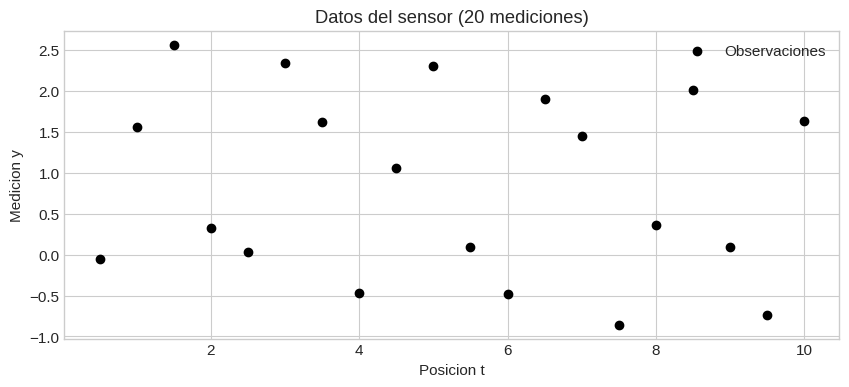

In [44]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [45]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.

    Args:
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        float -- error total (escalar)
    """
    # 1. Obtenemos las predicciones de nuestro modelo matemático usando
    # los parámetros actuales (params = [a, b, c, d]) y los tiempos observados
    y_pred = modelo_sensor(t_obs_p4, params)

    # 2. Calculamos la Suma de Errores al Cuadrado (SSE)
    # Restamos las observaciones reales menos nuestra predicción,
    # elevamos al cuadrado para penalizar errores grandes y sumamos todo.
    error = np.sum((y_obs_p4 - y_pred) ** 2)
    return error

def resolver_p4():
    """Resuelve el problema de calibracion.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a, b, c, d]
        error_opt: float -- error minimo encontrado
    """
    # differential_evolution solo necesita saber
    # qué función minimizar y en qué espacio buscar (bounds).

    resultado = differential_evolution(
        func=objetivo_p4,
        bounds=bounds_p4,
        strategy='best1bin', # Estrategia estándar de mutación
        popsize=15,          # Tamaño de la población (15 individuos por variable)
        seed=2026            # Fijamos la semilla para que tus resultados sean reproducibles
    )

    # Retornamos los 4 parámetros óptimos encontrados y el error mínimo
    return resultado.x, resultado.fun

Solucion P4:
  a = 1.5089
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


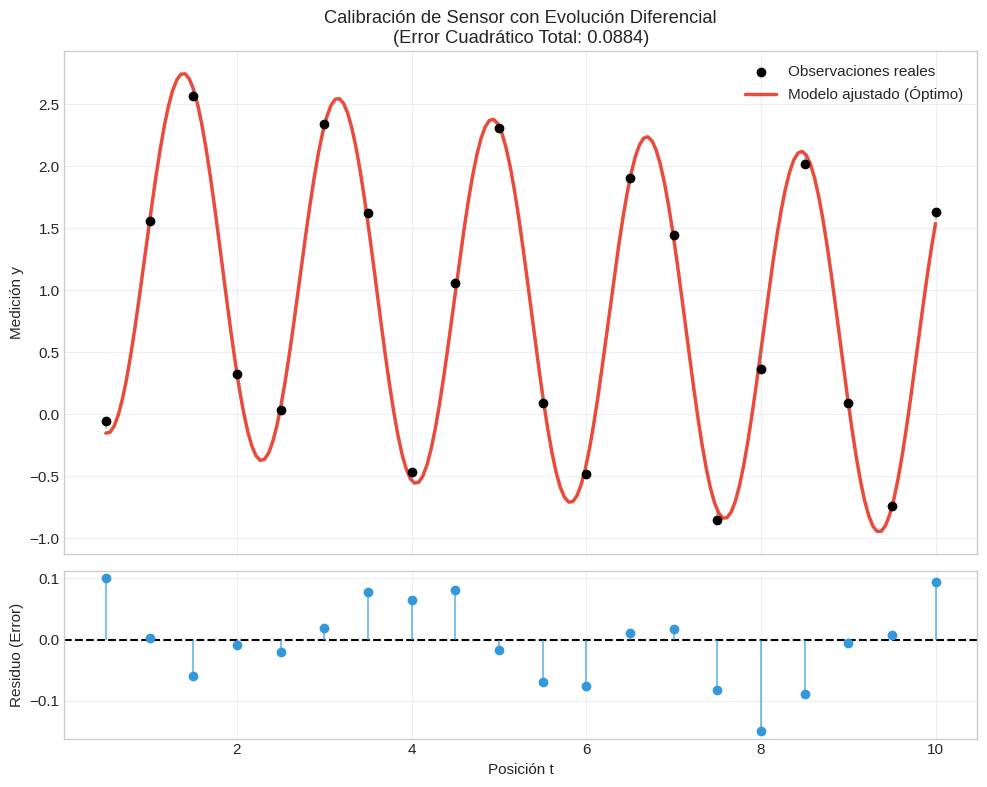

In [46]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos.

    Debe mostrar:
    - Datos observados (puntos)
    - Curva del modelo con parametros encontrados (linea)
    - Residuos (errores punto a punto)

    Args:
        params_opt: np.array (4,)
        error_opt: float
    """
    # Creamos una figura con dos subgráficas (arriba la curva, abajo los errores)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # 1. Generamos muchos puntos 't' para que la línea del modelo se dibuje súper suave
    t_fino = np.linspace(min(t_obs_p4), max(t_obs_p4), 200)
    y_fino = modelo_sensor(t_fino, params_opt)

    # 2. Calculamos las predicciones exactas en los puntos de observación
    # para poder dibujar las líneas de error (residuos)
    y_pred_obs = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred_obs

    # --- PANEL 1: EL AJUSTE ---
    # Dibujamos los puntos reales
    ax1.scatter(t_obs_p4, y_obs_p4, color="black", label="Observaciones reales", zorder=5)
    # Dibujamos nuestra curva óptima
    ax1.plot(t_fino, y_fino, color="#E74C3C", linewidth=2.5, label="Modelo ajustado (Óptimo)")

    # Dibujamos unas pequeñas líneas punteadas grises mostrando la distancia del error
    for t, y_real, y_pred in zip(t_obs_p4, y_obs_p4, y_pred_obs):
        ax1.plot([t, t], [y_real, y_pred], color="gray", linestyle="--", alpha=0.5)

    ax1.set_title(f"Calibración de Sensor con Evolución Diferencial\n(Error Cuadrático Total: {error_opt:.4f})")
    ax1.set_ylabel("Medición y")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- PANEL 2: LOS RESIDUOS ---
    # Una calibración perfecta tendría todos los residuos en la línea de cero
    ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax2.scatter(t_obs_p4, residuos, color="#3498DB", zorder=5)
    # Dibujamos palitos verticales desde el 0 hasta el residuo
    ax2.vlines(t_obs_p4, 0, residuos, color="#3498DB", alpha=0.6)
    ax2.set_xlabel("Posición t")
    ax2.set_ylabel("Residuo (Error)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

Tenemos dos tipos de variables.
Sea $y_i$ una variable binaria que indica si el CD $i$ se abre ($1$) o no ($0$), para $i \in \{1, 2, 3, 4\}$.
Sea $x_{ij}$ una variable continua que representa la cantidad de unidades enviadas desde el CD $i$ al cliente $j$, para $j \in \{1, 2, 3, 4, 5, 6\}$.

$$\begin{aligned}
y_i &\in {0, 1} \quad \text{para todo CD } i \\
x_{ij} &\geq 0 \quad \text{para todo CD } i \text{ y cliente } j
\end{aligned}$$

**Funcion objetivo:**

Queremos minimizar el costo total, que es la suma de los costos fijos de abrir los CDs más los costos variables de enviar los productos. Usando $f_i$ como el costo fijo y $c_{ij}$ como el costo de envío unitario:$$\min_{y, x} \sum_{i=1}^{4} f_i \cdot y_i + \sum_{i=1}^{4} \sum_{j=1}^{6} c_{ij} \cdot x_{ij}$$

**Restricciones:**

Tenemos que asegurar que los clientes reciban su producto (demanda), y que un CD no envíe más de lo que puede (capacidad) solamente si está abierto. Sea $D_j$ la demanda del cliente $j$ y $K_i$ la capacidad del CD $i$:$$\begin{aligned}\sum_{i=1}^{4} x_{ij} &= D_j \quad \text{para todo cliente } j \quad \text{(Cumplir demanda exacta)} \\
\sum_{j=1}^{6} x_{ij} &\leq K_i \cdot y_i \quad \text{para todo CD } i \quad \text{(Capacidad y activación)}\end{aligned}$$

### 5.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** Es de tipo Programación Lineal Entera Mixta (MILP)

**Justificacion (2-3 oraciones):** El problema pertenece a la categoría MILP, ya que combina variables de decisión discretas/binarias (abrir o no un centro de distribución) con variables de decisión continuas (la cantidad exacta de unidades a enviar). Dado que tanto la función objetivo como todas las restricciones son estrictamente lineales, se debe usar milp. Un solver lineal clásico como linprog fallaría porque podría sugerir respuestas absurdas (como "abrir el 45% de un CD"), mientras que milp utiliza el algoritmo de Branch-and-Bound (Ramificación y Acotamiento) para explorar el árbol de decisiones y garantizar el óptimo global exacto respetando la naturaleza binaria de las instalaciones.

In [47]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [48]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Args:
        y: np.array (4,) -- 1 si el CD esta abierto, 0 si no
        X: np.array (4, 6) -- unidades enviadas de CD i a cliente j

    Returns:
        float -- costo total
    """
    # Costo de abrir (vector 4, * vector 4,)
    costo_fijo = np.dot(costos_fijos_p5, y)
    # Costo de envío (multiplicación elemento a elemento de matrices y suma total)
    costo_envio = np.sum(costos_envio_p5 * X)
    return costo_fijo + costo_envio

def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones.

    Args:
        y: np.array (4,) -- apertura de CDs
        X: np.array (4, 6) -- envios

    Returns:
        dict con:
            'factible': bool
            'demanda_cumplida': np.array (6,) -- unidades recibidas por cada cliente
            'capacidad_usada': np.array (4,) -- capacidad usada por cada CD
    """
    # Sumamos las columnas de X para ver cuánto recibió cada cliente
    demanda_cumplida = np.sum(X, axis=0)
    # Sumamos las filas de X para ver cuánto envió cada CD
    capacidad_usada = np.sum(X, axis=1)

    tol = 1e-5
    # 1. ¿Recibieron los clientes exactamente lo que pedían?
    cumple_demanda = np.all(np.abs(demanda_cumplida - demandas_p5) < tol)

    # 2. ¿Lo enviado por cada CD no supera su límite (Capacidad * Si está abierto)?
    limite_actual = capacidades_p5 * y
    cumple_capacidad = np.all(capacidad_usada <= limite_actual + tol)

    factible = cumple_demanda and cumple_capacidad

    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada
    }

def resolver_p5():
    """Resuelve el problema de red de distribucion.

    Returns:
        y_opt: np.array (4,) -- 1 si el CD se abre, 0 si no
        X_opt: np.array (4, 6) -- envios optimos
        costo_opt: float -- costo total minimo
    """
    n_y = n_cds_p5                                # 4 variables binarias
    n_x = n_cds_p5 * n_clientes_p5                # 24 variables continuas
    total_vars = n_y + n_x                        # 28 variables totales

    # 1. Vector de costos c (juntamos los costos fijos y aplanamos la matriz de envío)
    c = np.concatenate([costos_fijos_p5, costos_envio_p5.flatten()])

    # 2. Tipos de variables (1 para entero/binario, 0 para continuo)
    es_entero = np.concatenate([np.ones(n_y), np.zeros(n_x)])

    # 3. Cotas: Las 'y' van de 0 a 1. Las 'x' van de 0 a infinito
    lb = np.zeros(total_vars)
    ub = np.full(total_vars, np.inf)
    ub[:n_y] = 1.0  # Topamos las binarias en 1
    limites = Bounds(lb, ub)

    # 4. Construir matriz de restricciones (A)
    # Necesitamos 6 filas para la demanda (igualdad) y 4 filas para la capacidad (desigualdad)
    A = np.zeros((n_clientes_p5 + n_cds_p5, total_vars))

    # Llenar restricciones de Demanda (Suma de x_ij = Demanda_j)
    for j in range(n_clientes_p5):
        for i in range(n_cds_p5):
            idx_x = n_y + i * n_clientes_p5 + j # Calcular posición en el vector plano
            A[j, idx_x] = 1.0

    # Llenar restricciones de Capacidad (Suma de x_ij - Capacidad_i * y_i <= 0)
    for i in range(n_cds_p5):
        fila_cap = n_clientes_p5 + i
        A[fila_cap, i] = -capacidades_p5[i]     # El coeficiente de y_i es negativo
        for j in range(n_clientes_p5):
            idx_x = n_y + i * n_clientes_p5 + j
            A[fila_cap, idx_x] = 1.0            # Los coeficientes de envíos son positivos

    # 5. Lados derechos (bounds de las restricciones)
    # Demanda es igualdad exacta (lb = ub). Capacidad es menor o igual a 0 (lb = -inf, ub = 0)
    lb_rest = np.concatenate([demandas_p5, np.full(n_cds_p5, -np.inf)])
    ub_rest = np.concatenate([demandas_p5, np.zeros(n_cds_p5)])
    restricciones = LinearConstraint(A, lb_rest, ub_rest)

    # 6. Resolver
    resultado = milp(c=c, integrality=es_entero, bounds=limites, constraints=restricciones)

    # 7. Desempacar el vector de 28 variables a nuestras estructuras originales
    y_opt = np.round(resultado.x[:n_y])
    X_opt = resultado.x[n_y:].reshape((n_cds_p5, n_clientes_p5))

    return y_opt, X_opt, resultado.fun

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


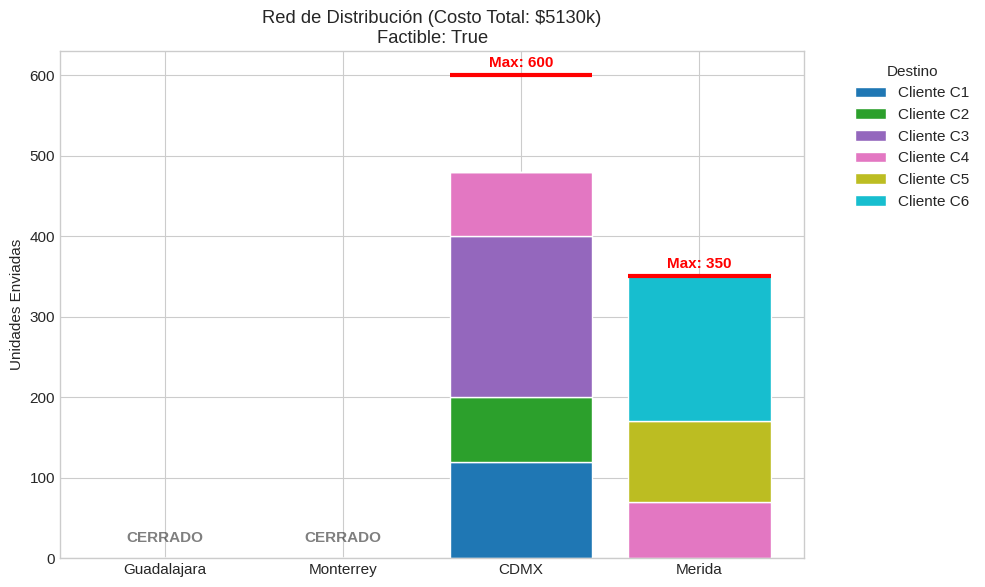

In [49]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion.

    Debe mostrar:
    - Que CDs estan abiertos (con capacidad usada vs disponible)
    - Flujo de envios: de cada CD a cada cliente

    Args:
        y_opt: np.array (4,)
        X_opt: np.array (4, 6)
        costo_opt: float
    """
    info = verificar_p5(y_opt, X_opt)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras apiladas: cada bloque de color representa un cliente distinto
    bottom = np.zeros(n_cds_p5)
    colores = plt.cm.tab10(np.linspace(0, 1, n_clientes_p5))

    for j in range(n_clientes_p5):
        envios_a_j = X_opt[:, j]
        ax.bar(ciudades_p5, envios_a_j, bottom=bottom, label=f'Cliente C{j+1}', color=colores[j], edgecolor="white")
        bottom += envios_a_j

    # Dibujar los topes máximos de capacidad para los CDs abiertos
    for i in range(n_cds_p5):
        if y_opt[i] > 0.5:
            # CD Abierto: Dibuja línea roja de capacidad
            ax.hlines(capacidades_p5[i], i-0.4, i+0.4, color="red", linewidth=3, zorder=5)
            ax.text(i, capacidades_p5[i] + 10, f'Max: {capacidades_p5[i]}', color="red", ha="center", fontweight="bold")
        else:
            # CD Cerrado
            ax.text(i, 20, "CERRADO", color="black", ha="center", fontweight="bold", alpha=0.5)

    ax.set_title(f"Red de Distribución (Costo Total: ${costo_opt:.0f}k)\nFactible: {info['factible']}")
    ax.set_ylabel("Unidades Enviadas")
    ax.legend(title="Destino", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print(f"Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)